<a href="https://colab.research.google.com/github/dian-l564/Despliegue/blob/main/categoria_precio_modelo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reglas de asociación -  Búsqueda de patrones
* Preparación: num-> cat (Discretización)
* Aprendizaje: apriori
* Evaluación: soporte y confianza
* Interpretación


In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica


# 1. Preparación de datos

In [3]:
data=pd.read_csv('categoria_precio.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26306 entries, 0 to 26305
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   model             26306 non-null  object 
 1   year              26306 non-null  int64  
 2   transmission      26306 non-null  object 
 3   mileage           26306 non-null  int64  
 4   fuelType          26306 non-null  object 
 5   tax               26306 non-null  int64  
 6   mpg               26306 non-null  float64
 7   engineSize        26306 non-null  float64
 8   brand             26306 non-null  object 
 9   categoria_precio  26306 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


In [4]:
data=data.copy()

In [5]:
#Ydata-profiling
# Cargar librería para Profiling
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00


array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'mileage'}>],
       [<Axes: title={'center': 'tax'}>, <Axes: title={'center': 'mpg'}>],
       [<Axes: title={'center': 'engineSize'}>, <Axes: >]], dtype=object)

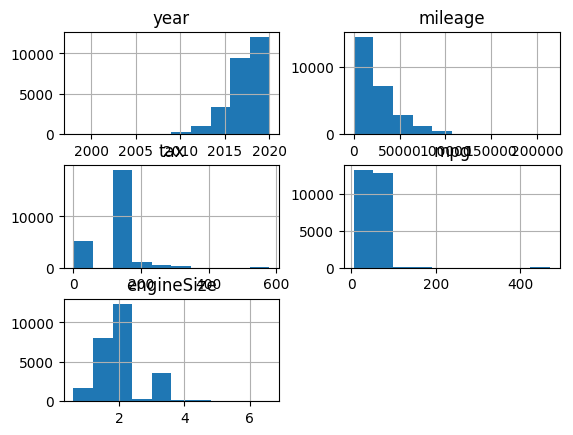

In [6]:
#Conocemos las variables numéricas
data.hist()


In [7]:
#Descripción estadística de variables numéricas


Text(0, 0.5, 'Frecuencia')

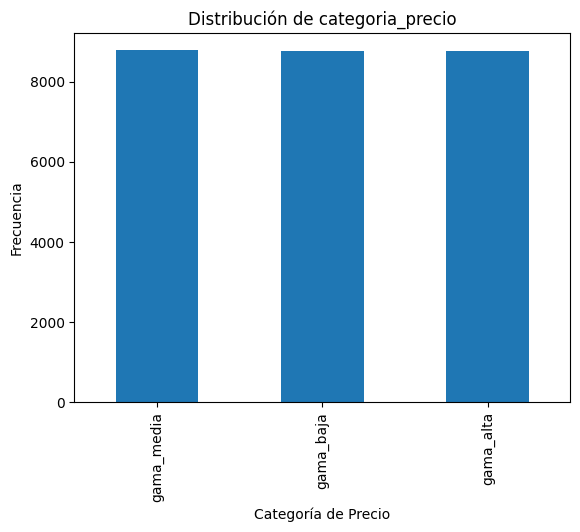

In [9]:
# Discretización: Cut

# Visualize the distribution of the already discretized 'categoria_precio' column
data['categoria_precio'].value_counts().plot(kind='bar')
plt.title('Distribución de categoria_precio')
plt.xlabel('Categoría de Precio')
plt.ylabel('Frecuencia')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26306 entries, 0 to 26305
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   model             26306 non-null  object 
 1   year              26306 non-null  int64  
 2   transmission      26306 non-null  object 
 3   mileage           26306 non-null  int64  
 4   fuelType          26306 non-null  object 
 5   tax               26306 non-null  int64  
 6   mpg               26306 non-null  float64
 7   engineSize        26306 non-null  float64
 8   brand             26306 non-null  object 
 9   categoria_precio  26306 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


In [ ]:
#Conversion


# 2. Aprendizaje

Para el algoritmo apriori todos los datos deben ser categóricos.

In [11]:
#Debemos instalar el paquete para el algoritmo apriori
!pip install -q apyori

  Preparing metadata (setup.py) ... done


In [13]:
from apyori import apriori
import pandas as pd # Ensure pandas is imported if not already in this cell

# The error 'TypeError: '<' not supported between instances of 'int' and 'str>'
# occurs because the apriori algorithm, when given `data.values`, attempts to
# sort or compare elements from different columns (like 'year' which is int64 and 'model' which is object/str).
# The apyori library expects all items within its transactions to be of a consistent, comparable type,
# typically strings representing categorical features.

# Fix: Preprocess the data to ensure all items are categorical strings.

# 1. Convert all columns in the DataFrame to string type.
# This handles both existing string columns and numerical columns by converting their values to strings.
data_str = data.astype(str)

# 2. Create the list of transactions. Each transaction is a list of strings,
# where each string combines the column name and its value (e.g., "year_2014", "fuelType_Petrol").
transactions = []
for index, row in data_str.iterrows():
    transaction = [f"{col}_{value}" for col, value in row.items()]
    transactions.append(transaction)

# Apply the apriori algorithm to the prepared transactions
# I'm lowering min_support and min_confidence from the original high values (0.50, 0.8)
# to more typical starting points (0.01, 0.1) to ensure rules are found,
# as itemsets created from all unique column_value pairs can be very sparse.
reglas = apriori(transactions, min_support=0.01, min_confidence=0.1)
reglas = list(reglas)

# Display the rules
reglas

[RelationRecord(items=frozenset({'brand_Audi'}), support=0.40549684482627535, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'brand_Audi'}), confidence=0.40549684482627535, lift=1.0)]),
 RelationRecord(items=frozenset({'brand_BMW'}), support=0.40983045692997794, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'brand_BMW'}), confidence=0.40983045692997794, lift=1.0)]),
 RelationRecord(items=frozenset({'brand_Hyundai'}), support=0.18467269824374669, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'brand_Hyundai'}), confidence=0.18467269824374669, lift=1.0)]),
 RelationRecord(items=frozenset({'categoria_precio_gama_alta'}), support=0.33300387744240856, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({'categoria_precio_gama_alta'}), confidence=0.33300387744240856, lift=1.0)]),
 RelationRecord(items=frozenset({'categoria_precio_gama_baja'}), support=0.33319

# 3. Evaluación


*   Soporte
*   Confianza




In [14]:
reglas = pd.DataFrame(reglas)
reglas

,items,support,ordered_statistics
0,(brand_Audi),0.405497,"[((), (brand_Audi), 0.40549684482627535, 1.0)]"
1,(brand_BMW),0.409830,"[((), (brand_BMW), 0.40983045692997794, 1.0)]"
2,(brand_Hyundai),0.184673,"[((), (brand_Hyundai), 0.18467269824374669, 1.0)]"
3,(categoria_precio_gama_alta),0.333004,"[((), (categoria_precio_gama_alta), 0.33300387..."
4,(categoria_precio_gama_baja),0.333194,"[((), (categoria_precio_gama_baja), 0.33319394..."
...,...,...,...
4550,"(engineSize_1.7, transmission_Manual, model_Tu...",0.011366,"[((engineSize_1.7), (transmission_Manual, mode..."
4551,"(engineSize_1.0, transmission_Manual, mpg_60.1...",0.010758,"[((engineSize_1.0), (transmission_Manual, mpg_..."
4552,"(engineSize_1.7, transmission_Manual, model_Tu...",0.010986,"[((engineSize_1.7), (transmission_Manual, mode..."
4553,"(engineSize_1.0, transmission_Manual, mpg_60.1...",0.010758,"[((engineSize_1.0), (transmission_Manual, mpg_..."


# **4 Interpretación**



### 1. Popularidad de Marcas y Categorías de Precio:

Las marcas `Audi` y `BMW` son las más frecuentes, con un soporte de aproximadamente 40.5% y 40.9% respectivamente. La categoría de precio `gama_alta` también es bastante común, apareciendo en alrededor del 33.3% de los registros. Esto sugiere que estos atributos son muy representados en el dataset.

### 2. Tendencia de Modelos `Audi` del Año `2020` con Transmisión `Semi-Automática`:

Existe una regla que indica que si el `año` del vehículo es `2020`, hay una confianza del 26.4% de que sea un `Audi` con `transmisión_Semi-Auto`. El `lift` de 1.94 sugiere que esta combinación es casi el doble de probable en autos del 2020 en comparación con el conjunto de datos general. Esto podría ser útil para entender las preferencias de modelos recientes.

### 3. `BMW` con `Motor_2.0` y `Categoría_Alta`:

Una regla interesante es que los vehículos `BMW` con `engineSize_2.0` tienen un 37.7% de confianza de pertenecer a la `categoria_precio_gama_alta`. El valor de `lift` de 1.13 indica una correlación positiva, aunque moderada, entre estas características, lo que sugiere que estos modelos tienden a estar en el segmento de precios más altos.

### 4. Fuerte Asociación de `BMW` con `Motor_3.0` y `Categoría_Alta`:

La regla que relaciona `BMW` con `engineSize_3.0` y la `categoria_precio_gama_alta` muestra una confianza significativamente mayor del 61.5%. Con un `lift` de 1.85, se evidencia una fuerte correlación: los `BMW` con un motor de 3.0 litros son casi el doble de propensos a ser de la `gama_alta` de precios. Esto es una indicación clara de que los modelos `BMW` con motores más grandes se posicionan consistentemente en el segmento de lujo.

Distribución de clases (train):
 categoria_precio
gama_alta     7066
gama_media    6990
gama_baja     6988
Name: count, dtype: int64
Regresión logística    CV10 acc=0.884 ± 0.004 | Test acc=0.887
Árbol de decisión      CV10 acc=0.880 ± 0.002 | Test acc=0.890
Random Forest          CV10 acc=0.906 ± 0.008 | Test acc=0.917

Mejor modelo: Random Forest
              precision    recall  f1-score   support

   gama_baja      0.935     0.918     0.926      1777
  gama_media      0.868     0.892     0.880      1791
   gama_alta      0.952     0.942     0.947      1694

    accuracy                          0.917      5262
   macro avg      0.918     0.917     0.918      5262
weighted avg      0.917     0.917     0.917      5262


Top 10 variables:
 num__mileage                   0.189005
num__year                      0.183411
num__mpg                       0.121991
num__tax                       0.091801
num__engineSize                0.084356
cat__transmission_Manual       0.059183
cat__tra

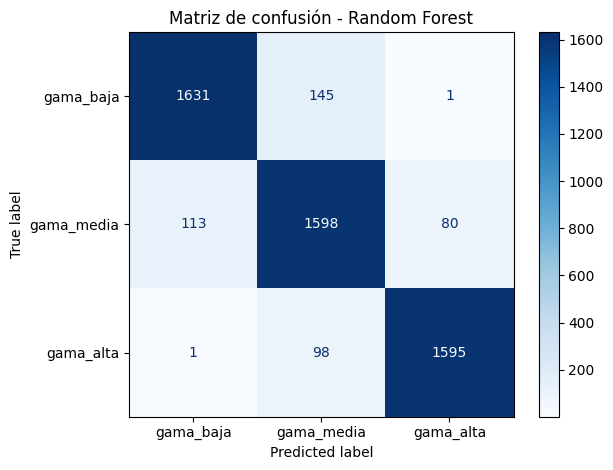

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer # Corrected import for ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 2. Dividir ANTES de crear la etiqueta (los cortes se calculan solo con train -> sin fuga de información)

X = data.drop(columns=["categoria_precio"])
y = data["categoria_precio"] # Use the existing categorical column as target

train_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=42)

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
print("Distribución de clases (train):\n", y_train.value_counts())

# 3. Preprocesamiento (price NO entra como atributo)
cat = ["model", "transmission", "fuelType", "brand"]
num = ["year", "mileage", "tax", "mpg", "engineSize"]
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ("num", StandardScaler(), num),
])

# 4. Modelos a comparar
modelos = {
    "Regresión logística": LogisticRegression(max_iter=2000),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=12, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=42),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
resultados = {}
for nombre, m in modelos.items():
    pipe = Pipeline([("prep", prep), ("clf", m)])
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    resultados[nombre] = (pipe, cv_acc.mean(), acc)
    print(f"{nombre:22s} CV10 acc={cv_acc.mean():.3f} \u00b1 {cv_acc.std():.3f} | Test acc={acc:.3f}")

# 5. Evaluación detallada del mejor modelo
mejor = max(resultados, key=lambda k: resultados[k][2])
pipe = resultados[mejor][0]
pred = pipe.predict(X_test)
# The labels should match the actual categories in 'categoria_precio'
orden = y.unique().tolist() # Dynamically get the order from unique values or define if a specific order is needed
print(f"\nMejor modelo: {mejor}")
print(classification_report(y_test, pred, labels=orden, digits=3))
cm = confusion_matrix(y_test, pred, labels=orden)
ConfusionMatrixDisplay(cm, display_labels=orden).plot(cmap="Blues")
plt.title(f"Matriz de confusi\u00f3n - {mejor}")
plt.tight_layout(); plt.savefig("matriz_confusion.png", dpi=120)

# 6. Importancia de variables (si es Random Forest)
if mejor == "Random Forest":
    nombres = pipe.named_steps["prep"].get_feature_names_out()
    imp = pd.Series(pipe.named_steps["clf"].feature_importances_, index=nombres)
    print("\nTop 10 variables:\n", imp.sort_values(ascending=False).head(10))

# 7. Predicción para un vehículo nuevo
nuevo = pd.DataFrame([{"model": "3 Series", "year": 2018, "transmission": "Automatic",
                       "mileage": 30000, "fuelType": "Diesel", "tax": 145, "mpg": 55.0,
                       "engineSize": 2.0, "brand": "BMW"}])
print("\nPredicci\u00f3n veh\u00edculo nuevo:", pipe.predict(nuevo)[0],
      dict(zip(pipe.classes_, pipe.predict_proba(nuevo)[0].round(3))))